# Puerto Rico Real Estate Price Analysis: What Factors are Associated with Home Prices?

## Project Goal
This project analyzes real-estate listings in Puerto Rico to explore the factors associated with home prices. The analysis focuses on property characteristics for example: number of bedrooms, bathrooms, lot size, house size, and location.

## Questions
1. Which Puerto Rico cities have the highest average home prices?
2. Are homes with more bedrooms and bathrooms generally more expensive?
3. How is house size associated with price?
4. What property characteristics appear most related to home price?

## Tools Used
- Python
- Jupyter Notebook
- pandas
- Matplotlib
- Seaborn

## Data Source
USA Real Estate Dataset from Kaggle

In [3]:
from pathlib import Path

data_folder = Path.home() / "Downloads" / "data"
list(data_folder.iterdir())

[WindowsPath('C:/Users/nemes/Downloads/data/realtor-data.cvs.csv')]

In [4]:
import pandas as pd

df = pd.read_csv(data_folder / "realtor-data.cvs.csv")
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


## 1. Data Cleaning

The original dataset includes listings from across the US. For this project, I filtered the data to my country of residence Puerto Rico. I also removed records with missing information in key variables and excluded extreme values that could distort the analysis.

In [5]:
# Keep PR listings that are currently for sale
pr_df = df[(df["state"] == "Puerto Rico") & (df["status"] == "for_sale")].copy()

# Remove rows with missing key info
pr_df = pr_df.dropna(subset=["price", "bed", "bath", "house_size", "city"])

# Remove extreme values
pr_df = pr_df[
    (pr_df["price"] >= 25000) &
    (pr_df["price"] <= 5000000) &
    (pr_df["bed"] <= 10) &
    (pr_df["bath"] <= 10) &
    (pr_df["house_size"] >= 400) &
    (pr_df["house_size"] <= 10000)]

print("Clean PR listings:", pr_df.shape)
pr_df.head()

Clean PR listings: (1983, 12)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
5,103378.0,for_sale,179000.0,4.0,3.0,0.46,1850806.0,San Sebastian,Puerto Rico,612.0,2520.0,NaN


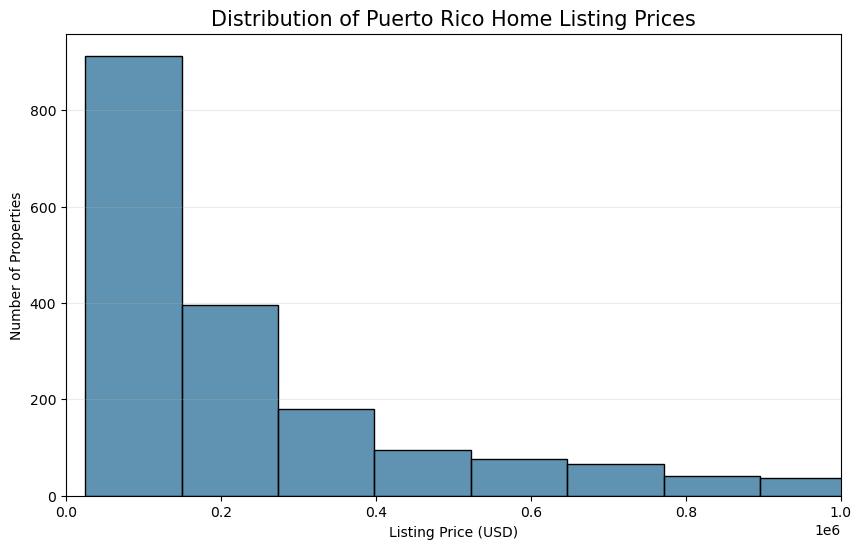

Average listing price: $418,439
Median listing price: $164,432


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Price Distribution
#Created a histogram to visualize the distribution of home listing prices in PR.
#Calculated the average and median prices.
plt.figure(figsize=(10, 6))

sns.histplot(pr_df["price"], bins=40, color="#2A6F97")

plt.title("Distribution of Puerto Rico Home Listing Prices", fontsize=15)
plt.xlabel("Listing Price (USD)")
plt.ylabel("Number of Properties")
plt.xlim(0, 1000000)
plt.grid(axis="y", alpha=0.25)

plt.show()

print("Average listing price: ${:,.0f}".format(pr_df["price"].mean()))
print("Median listing price: ${:,.0f}".format(pr_df["price"].median()))

### Interpretation

Most Puerto Rico listings in this dataset are priced below $400,000. The average price is higher than the median price because a smaller number of high-priced homes pull the average upward. Listing prices are right-skewed.

## 3. Average Home Price by City
Calculated the average listing price for cities with at least 10 listings for more options.

In [7]:
# Average price and number of listings for each city
city_summary = (
    pr_df.groupby("city")
    .agg(
        average_price=("price", "mean"),
        listing_count=("price", "count"))
    .query("listing_count >= 10")
    .sort_values("average_price", ascending=False))

# top 10 cities with the highest average prices
top_10_cities = city_summary.head(10)

display(top_10_cities.style.format({"average_price": "${:,.0f}"}))

,average_price,listing_count
city,,
Dorado,"$1,339,198",60
San Juan,"$739,532",346
Rincon,"$699,452",21
Humacao,"$698,436",80
Vieques,"$679,385",54
Guaynabo,"$661,980",115
Isabela,"$431,627",22
Aguada,"$403,882",22
Fajardo,"$370,053",38


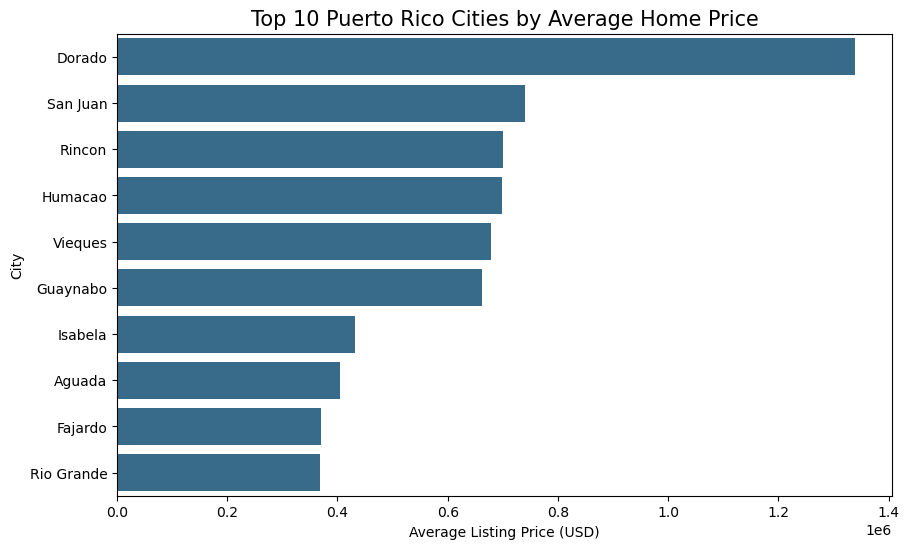

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_cities.reset_index(),
    x="average_price",
    y="city",
    color="#2A6F97")

plt.title("Top 10 Puerto Rico Cities by Average Home Price", fontsize=15)
plt.xlabel("Average Listing Price (USD)")
plt.ylabel("City")
plt.show()

#### Interpretation

Dorado had the highest average listing price among Puerto Rico cities (makes sense).

## 4. Median Listing Price by Number of Bedrooms

Compared the median listing price across homes with different numbers of bedrooms. 

In [9]:
bedroom_summary = (
    pr_df[pr_df["bed"].between(1, 4)]
    .groupby("bed")
    .agg(
        median_price=("price", "median"),
        listing_count=("price", "count"))
    .reset_index())

display(bedroom_summary.style.format({"median_price": "${:,.0f}"}))

,bed,median_price,listing_count
0,1.000000,"$249,000",72
1,2.000000,"$177,000",230
2,3.000000,"$125,000",940
3,4.000000,"$236,250",400


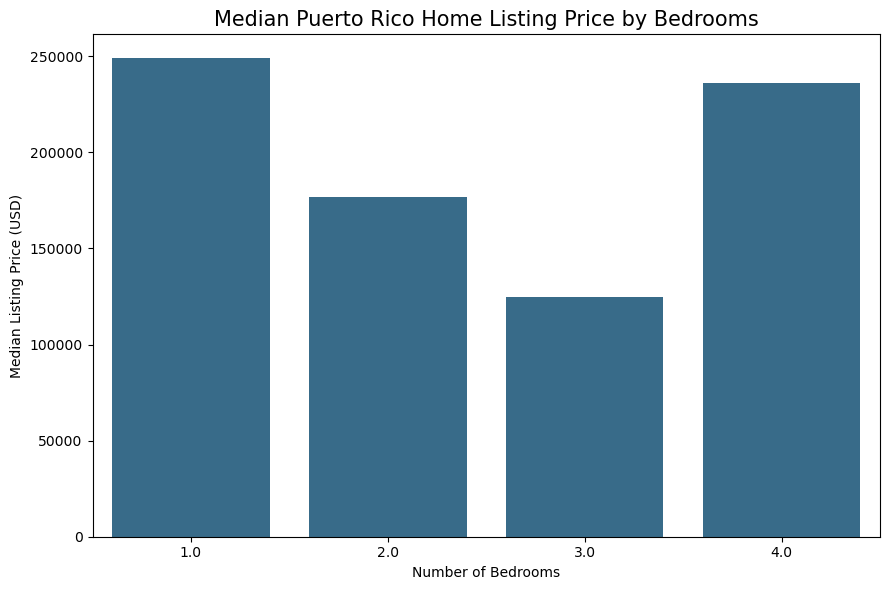

In [11]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=bedroom_summary,
    x="bed",
    y="median_price",
    color="#2A6F97")

plt.title("Median Puerto Rico Home Listing Price by Bedrooms", fontsize=15)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Listing Price (USD)")
plt.tight_layout()
plt.show()

### Interpretation
The results do not show a consistent increase in price as the number of bedrooms increases. In this dataset, one-bedroom and four-bedroom homes had higher median listing prices than two- and three-bedroom homes. This suggests that location, home size, and property type may also strongly influence price. 

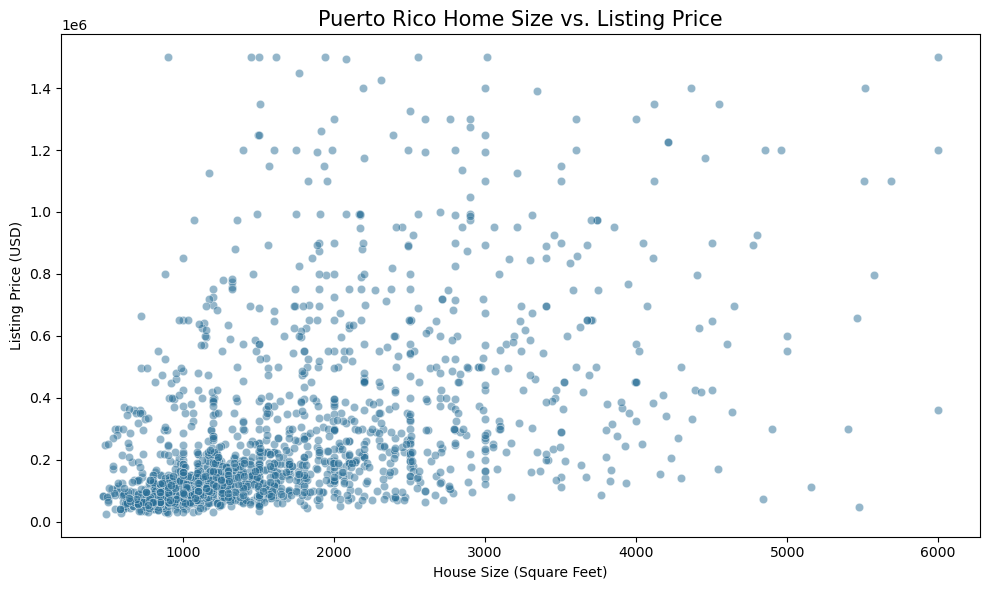

Correlation between house size and listing price: 0.52


In [12]:
# scatterplot to examine the relationship between house size and listing price
size_df = pr_df[
    (pr_df["house_size"] <= 6000) &
    (pr_df["price"] <= 1500000)
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_df,
    x="house_size",
    y="price",
    alpha=0.5,
    color="#2A6F97")

plt.title("Puerto Rico Home Size vs. Listing Price", fontsize=15)
plt.xlabel("House Size (Square Feet)")
plt.ylabel("Listing Price (USD)")
plt.tight_layout()
plt.show()

correlation = size_df["house_size"].corr(size_df["price"])
print("Correlation between house size and listing price:", round(correlation, 2))

### Interpretation
Moderate positive relationship between house size and listing price - larger homes tend to be listed at higher prices,
but size alone does not determine price. To me, location matters most. 

### Conclusion
- Most listings in the cleaned dataset were priced below $400,000.
- Dorado had the highest average listing price among cities with at least 10 listings.
- The number of bedrooms did not have a perfectly consistent relationship with price.
- Home size had a moderate positive relationship with listing price: larger homes generally tended to be listed at higher prices.
- Location and characteristics beyond bedrooms and size likely play an important role in home prices.

### Limitations

It is a relatively small dataset, will need updated information for durther clarifictaions.